<center><h1> FIL2000 - Ética Aplicada a Inteligencia Artificial </h1><center>
<center><h2> Taller Sumativo 1: Modelos interpretables y xAI <h2><center>  

**Alumno:** Armando Arredondo Valle


# `Instrucciones generales`
Completa las partes de este notebook y escribe un informe que contenga tus resultados.


## Estructura del informe

| Sección | Contenido esperado | Puntaje |
|---|---|---|
| **Introducción** | Contextualiza brevemente el problema explicando los conceptos clave: XAI, LIME y SHAP. | 10% |
| **Parte I — LIME** | Carga el modelo BETO, define las frases de interés y aplica LIME. Visualiza e interpreta las contribuciones de cada token y responde las preguntas guiadas. | 25% |
| **Parte II — SHAP** | Entrena el Random Forest, calcula los SHAP values y visualiza las variables más influyentes. Interpreta qué features determinan las predicciones y por qué eso es relevante en el contexto del problema. | 25% |
| **Análisis comparativo** | Compara LIME y SHAP técnicamente considerando: tipo de interpretabilidad (local o global), supuestos y limitaciones. Apoya la comparación con ejemplos concretos de tus propios resultados. finalmente responde ¿Qué tipo de explicaciones podríamos generar con esta información? | 25% |
| **Código** | El código es legible, está bien implementado y cuenta con documentación mínima. | 15% |

## `Temas formales`

**Modalidad:** Debe realizarse de manera individual

**Formato de entrega:** El trabajo debe elaborarse y entregarse a través de Canvas. Tanto el Jupyter como el informe deben entregarse en formato PDF.

**Extensión:** Máximo 4 planas.

**Formato del documento:**
- Citas: APA 7
- Formato: dos columnas
- Fuente: Times New Roman, tamaño 12
- Interlineado: 1,5

**No es necesario justificar resultados o métodos o responder preguntas directamente en el Jupyter**, pero el informe sí debe incluir los resultados y las reflexiones planteadas en él. Toda métrica o visualización que no esté acompañada de una explicación no será considerada en la evaluación.

## `Integridad académica y uso de IA`

El uso de asistentes de IA para apoyarse con código no está prohibido, pero debe ser documentado. Pueden usar IA para entender mejor un código o concepto, resolver dudas de sintaxis, identificar y entender bugs, y buscar información o referencias. No pueden usar IA para generar el código completo del taller, reemplazar su razonamiento en decisiones importantes de la tarea, definir automáticamente qué limpiar, normalizar o estandarizar en los datos, determinar la secuencia de pasos de su solución, ni decidir la estrategia de optimización del código. La redacción del informe sigue los lineamientos de integridad académica del curso.

No está permitida la copia completa o parcial entre distintos estudiantes. Cualquier uso no documentado o irresponsable de IA, o plagio, será considerado una falta a la integridad académica.

Si tienen dudas sobre el uso de IA o la citación de código externo, no duden en preguntar. Pueden usar libremente los códigos de los talleres formativos.


## `Importante`

**Lean la rúbrica antes de escribir su informe.**


In [1]:
# imports generales
from transformers import pipeline
from lime.lime_text import LimeTextExplainer
import numpy as np
import matplotlib.pyplot as plt

d:\Maestria-IA\Etica\Laboratorios\Laboratorio1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parte 1: Interpretabilidad local con LIME

En esta parte aplicarás la técnica LIME para obtener explicaciones locales de un modelo de análisis de sentimiento en español.

## Parte 1.1 :

Contexto y motivación (definir antes de escribir código)
Decide brevemente el contexto de tu análisis:

1. ¿Qué tipo de frases vas a analizar? (comentarios de redes sociales, titulares de noticias, reseñas, frases con estereotipos, etc.). Crea o recopila al menos 10 frases.

2. ¿Qué quieres descubrir o investigar con LIME? Por ejemplo: ¿el modelo clasifica correctamente el sarcasmo?, ¿existen sesgos de género en las predicciones?, ¿cómo se comporta ante lenguaje coloquial chileno?


## Parte 1.2:

Carga el modelo BETO de análisis de sentimientos.

Obtén la predicción del modelo para cada frase e identifica si los resultados son consistentes con lo que esperabas.
Aplica LIME para obtener la explicación local de al menos 3 frases. Para cada una: visualiza las contribuciones de cada palabra con un gráfico de barras.

Interpreta los resultados: ¿qué palabras están dominando cada predicción? ¿Hay palabras que no esperabas que tuvieran ese peso? ¿Las explicaciones son coherentes con el significado de la frase?

### Contexto y motivación

Voy a trabajar con reseñas de productos y servicios en español coloquial, incluyendo expresiones chilenas ("la raja", "bacán", "caleta", "piola"). Esto es relevante desde una perspectiva ética porque los modelos de análisis de sentimiento entrenados en corpus formales pueden fallar sistemáticamente con el lenguaje informal de ciertos grupos sociodemográficos, lo que genera sesgos de representación: si una herramienta de monitoreo de opinión pública no entiende cómo se expresan ciertos usuarios, sus voces quedan invisibilizadas en el análisis.

**Lo que busco investigar con LIME:** Quiero ver si las palabras que BETO usa para clasificar el sentimiento son coherentes con el significado real de la frase, o si hay tokens que dominan la predicción de forma inesperada. En particular, me interesa cómo maneja los modismos chilenos que probablemente no están representados en sus datos de entrenamiento, y si LIME me permite detectar esos puntos ciegos del modelo.

In [2]:
frases = [
    "El producto llegó super rápido y funciona perfecto, muy contento con la compra",
    "Pésimo servicio, me tuvieron esperando una hora y al final no me resolvieron nada",
    "La verdad no es ni bueno ni malo, cumple pero nada especial",
    "La atención fue la raja, el tipo me explicó todo con paciencia",
    "Me llegó todo roto y nadie se hace cargo, nunca más compro acá",
    "Está piola el producto, no es wow pero sirve para lo que necesitaba",
    "La app se cae cada dos minutos, es horrible intentar pagar con esto",
    "Bacán la experiencia, el local es bonito y la comida estaba buena",
    "Pedí devolución hace un mes y todavía no me devuelven la plata, una vergüenza",
    "El envío demoró caleta pero al final el producto era justo lo que buscaba",
    "Malísimo, se echó a perder a la semana de uso",
    "Recomendado al 100%, mis viejos quedaron contentos con el regalo"
]

In [3]:
clasificador = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    top_k=None
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2456.10it/s]


In [4]:
for i, frase in enumerate(frases):
    resultado = clasificador(frase)
    top = max(resultado[0], key=lambda x: x['score'])
    print(f"Frase {i+1}: {top['label']} ({top['score']:.3f})")
    print(f"  >> {frase}\n")

Frase 1: 5 stars (0.809)
  >> El producto llegó super rápido y funciona perfecto, muy contento con la compra

Frase 2: 1 star (0.902)
  >> Pésimo servicio, me tuvieron esperando una hora y al final no me resolvieron nada

Frase 3: 3 stars (0.521)
  >> La verdad no es ni bueno ni malo, cumple pero nada especial

Frase 4: 5 stars (0.290)
  >> La atención fue la raja, el tipo me explicó todo con paciencia

Frase 5: 1 star (0.915)
  >> Me llegó todo roto y nadie se hace cargo, nunca más compro acá

Frase 6: 3 stars (0.470)
  >> Está piola el producto, no es wow pero sirve para lo que necesitaba

Frase 7: 1 star (0.851)
  >> La app se cae cada dos minutos, es horrible intentar pagar con esto

Frase 8: 4 stars (0.398)
  >> Bacán la experiencia, el local es bonito y la comida estaba buena

Frase 9: 1 star (0.946)
  >> Pedí devolución hace un mes y todavía no me devuelven la plata, una vergüenza

Frase 10: 3 stars (0.439)
  >> El envío demoró caleta pero al final el producto era justo lo que b

In [5]:
# wrapper para que LIME pueda usar el clasificador
# necesita recibir una lista de textos y devolver probabilidades
def predict_proba(textos):
    resultados = clasificador(textos, batch_size=8)
    probs = []
    for res in resultados:
        sorted_res = sorted(res, key=lambda x: x['label'])
        probs.append([r['score'] for r in sorted_res])
    return np.array(probs)

nombres_clases = ['1 star', '2 stars', '3 stars', '4 stars', '5 stars']
explainer = LimeTextExplainer(class_names=nombres_clases)

In [6]:
# explicaciones para frases que me parecen interesantes:
# - la positiva clara (0)
# - la negativa clara (1)
# - la que tiene modismo chileno positivo "la raja" (3)
# - la negativa de la app (6)
indices = [0, 1, 3, 6]

for idx in indices:
    print(f"\n=== Frase {idx+1}: \"{frases[idx]}\" ===")

    exp = explainer.explain_instance(
        frases[idx],
        predict_proba,
        num_features=8,
        num_samples=500
    )

    pred = max(clasificador(frases[idx])[0], key=lambda x: x['score'])
    print(f"Predicción: {pred['label']} ({pred['score']:.3f})")

    # mostrar contribuciones por palabra (uso label del explainer)
    top_label = exp.available_labels()[0]
    for palabra, peso in exp.as_list(label=top_label):
        signo = '+' if peso > 0 else ''
        print(f"  {palabra}: {signo}{peso:.4f}")


=== Frase 1: "El producto llegó super rápido y funciona perfecto, muy contento con la compra" ===
Predicción: 5 stars (0.809)
  perfecto: -0.0063
  contento: -0.0046
  super: -0.0034
  funciona: -0.0033
  muy: -0.0026
  rápido: -0.0018
  llegó: +0.0013
  compra: -0.0011

=== Frase 2: "Pésimo servicio, me tuvieron esperando una hora y al final no me resolvieron nada" ===
Predicción: 1 star (0.902)
  Pésimo: -0.1560
  me: +0.0282
  final: +0.0247
  hora: -0.0214
  servicio: -0.0202
  esperando: +0.0174
  nada: -0.0148
  no: +0.0141

=== Frase 4: "La atención fue la raja, el tipo me explicó todo con paciencia" ===
Predicción: 5 stars (0.290)
  atención: +0.0509
  paciencia: -0.0498
  raja: +0.0419
  todo: -0.0391
  la: -0.0366
  explicó: +0.0213
  tipo: +0.0209
  con: -0.0199

=== Frase 7: "La app se cae cada dos minutos, es horrible intentar pagar con esto" ===
Predicción: 1 star (0.851)
  horrible: -0.1364
  pagar: -0.0200
  con: +0.0182
  se: +0.0158
  es: +0.0154
  dos: +0.0146
  La:

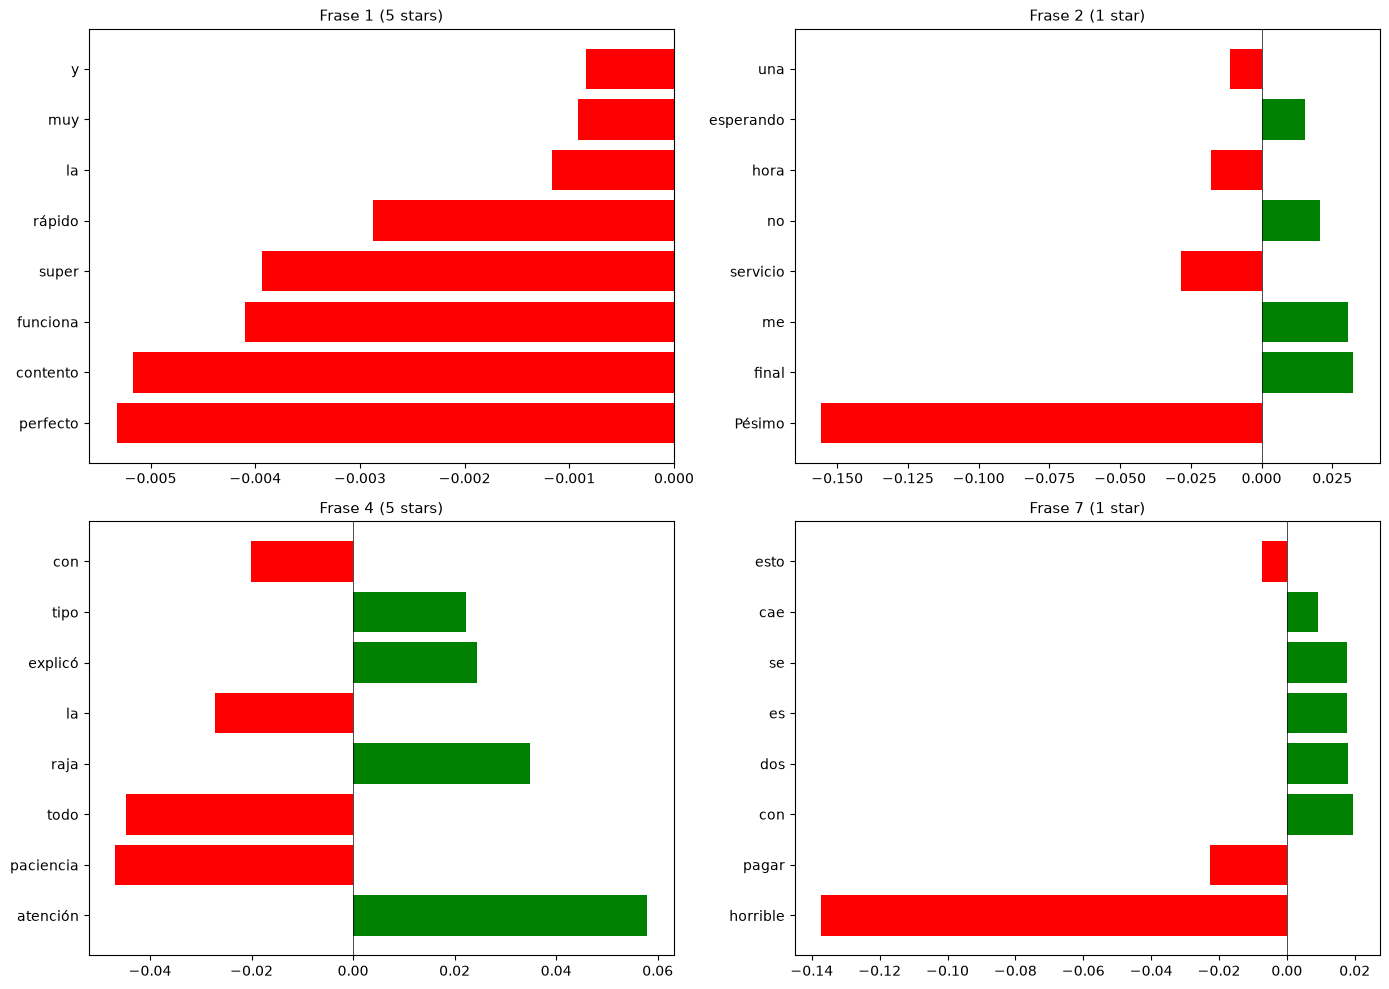

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    exp = explainer.explain_instance(
        frases[idx],
        predict_proba,
        num_features=8,
        num_samples=500
    )

    pred = max(clasificador(frases[idx])[0], key=lambda x: x['score'])
    top_label = exp.available_labels()[0]
    contribuciones = exp.as_list(label=top_label)

    palabras = [c[0] for c in contribuciones]
    pesos = [c[1] for c in contribuciones]
    colores = ['green' if p > 0 else 'red' for p in pesos]

    axes[i].barh(palabras, pesos, color=colores)
    axes[i].set_title(f'Frase {idx+1} ({pred["label"]})', fontsize=11)
    axes[i].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('lime_contribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Parte 2 : Explicabilidad de Random Forest con SHAP

En esta segunda parte del taller se trabajará con datos del área médica, en específico con lo que respecta a la enfermedad real crónica (CDK). Para entrenar un modelo de Random Forest, aplicando SHAP para conocer los factores/valores que explican los resultados.

## Datos

El dataset a utilizar proviene desde el repositorio de UCI Machine Learning Repository. Se dejan a continuación algunos metadatos:

- Entradas: 400
- Variables :
- Faltan valores : Sí

Las variables que se encuentran especificadas son :

| variable | definición | unidad |
|----------|----------|----------|
|age| Edad| año|
|bp| Presión Sanguínea| mm/Hg
|sg | Densidad relativa|
|al| Albúmina|
|su| Azúcar|
|rbc| Glóbulos rojos|
|pc| Células de pus|
|pcc| Cúmulo de células de pus|
|ba| Bacterias|
|bgr |Glucosa aleatoria| mgs/dl
|bu| Urea Sanguínea| mgs/dl
|sc| Creatinina sérica| mgs/dl
|sod| Sodio| mEq/L|
|pot| Potasio| mEq/L|
|hemo| Hemoglobina| mEq/L|
|pcv| Volumen de células empaquetadas|
|wbcc| Cantidad de Glóbulos Blancos| cells/cmm.|
|rbcc| Cantidad de Glóbulos rojos| millions/cmm|  
|htn| Hipertensión |  
|dm| Diabetes mellitus|
|cad| Enfermedades Arterias Coronarias|
|appet| Apetito|
|pe| Edema Podal|
|ane| Anemia|
|class (TARGET)| ckd / no ckd|


## `Importante` : Acceso a los datos

Puedes revisar el repositorio fuente aquí :  https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

- Por comodidad se recomienda importar el dataset, ya que los archivos originales están en tipo ".arff"
- Puedes trabajar cargando los archivos manualmente o importanto los datos. A continuación te dejamos la importación en python entregada por el repositorio oficial.

In [8]:
pip install ucimlrepo --quiet

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

## 2.1 Carga y limpieza de datos

In [10]:
from ucimlrepo import fetch_ucirepo

chronic_kidney_disease = fetch_ucirepo(id=336)

X = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets

# junto todo en un df para poder explorar mejor
df = pd.concat([X, y], axis=1)
print(f"Shape: {df.shape}")
df.head()

Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [11]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
print("Columnas con nulos:")
print(nulos_pct[nulos_pct > 0].sort_values(ascending=False))

Columnas con nulos:
rbc      38.0
rbcc     32.8
wbcc     26.5
pot      22.0
sod      21.8
pcv      17.8
pc       16.2
hemo     13.0
su       12.2
sg       11.8
al       11.5
bgr      11.0
bu        4.8
sc        4.2
bp        3.0
age       2.2
pcc       1.0
ba        1.0
htn       0.5
dm        0.5
cad       0.5
appet     0.2
pe        0.2
ane       0.2
dtype: float64


In [12]:
df.dtypes

age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc          str
pc           str
pcc          str
ba           str
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn          str
dm           str
cad          str
appet        str
pe           str
ane          str
class        str
dtype: object

In [13]:
# separar categoricas de numericas
cols_cat = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']
cols_num = [c for c in df.columns if c not in cols_cat]

# algunas columnas numericas vienen como object (hay \t y ? en los datos)
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# limpiar espacios raros en las categoricas
for col in cols_cat:
    df[col] = df[col].str.strip()

print(df.dtypes)

age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc          str
pc           str
pcc          str
ba           str
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn          str
dm           str
cad          str
appet        str
pe           str
ane          str
class        str
dtype: object


In [14]:
# imputar nulos
# numericas: mediana (mejor que media para datos medicos con outliers)
for col in cols_num:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# categoricas: moda
for col in cols_cat:
    if col != 'class' and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Nulos restantes: {df.isnull().sum().sum()}")

Nulos restantes: 0


In [15]:
# codificar categoricas - como son binarias las mapeo directo
mapeos = {
    'rbc': {'normal': 0, 'abnormal': 1},
    'pc': {'normal': 0, 'abnormal': 1},
    'pcc': {'notpresent': 0, 'present': 1},
    'ba': {'notpresent': 0, 'present': 1},
    'htn': {'no': 0, 'yes': 1},
    'dm': {'no': 0, 'yes': 1},
    'cad': {'no': 0, 'yes': 1},
    'appet': {'good': 0, 'poor': 1},
    'pe': {'no': 0, 'yes': 1},
    'ane': {'no': 0, 'yes': 1}
}

for col, m in mapeos.items():
    df[col] = df[col].map(m)

df['class'] = df['class'].map({'ckd': 1, 'notckd': 0})

print(f"Nulos post-codificacion: {df.isnull().sum().sum()}")
df.head()

Nulos post-codificacion: 0


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,0,0,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,0,0,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,0,0,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,0,1,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,1


In [16]:
# si quedan nulos por valores que no calzaron con el mapeo, los saco
antes = len(df)
df = df.dropna()
print(f"Eliminé {antes - len(df)} filas con nulos restantes")
print(f"Shape final: {df.shape}")

Eliminé 0 filas con nulos restantes
Shape final: (400, 25)


## 2.2 División del conjunto de datos

In [17]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Distribución en train: {y_train.value_counts(normalize=True).to_dict()}")

Train: 320 | Test: 80
Distribución en train: {1: 0.625, 0: 0.375}


## 2.3 Estandarización

Uso MinMaxScaler. El Random Forest en sí no necesita escalado, pero tener todo en [0,1] hace que los SHAP values sean más fáciles de interpretar visualmente cuando comparo features con rangos muy distintos (ej: edad vs creatinina).

In [18]:
# solo escalo las numericas, las binarias ya estan en 0/1
cols_num_final = [c for c in cols_num if c in X_train.columns]

scaler = MinMaxScaler()

X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

X_train_sc[cols_num_final] = scaler.fit_transform(X_train[cols_num_final])
X_test_sc[cols_num_final] = scaler.transform(X_test[cols_num_final])

X_train_sc.describe().round(3)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
count,320.000,320.000,320.000,320.000,320.000,320.000,320.000,320.000,320.000,320.000,...,320.000,320.000,320.000,320.000,320.000,320.000,320.000,320.000,320.000,320.000
mean,0.559,0.207,0.636,0.176,0.068,0.112,0.197,0.122,0.062,0.257,...,0.642,0.665,0.252,0.601,0.366,0.319,0.078,0.194,0.181,0.153
std,0.193,0.107,0.268,0.259,0.194,0.316,0.398,0.328,0.242,0.153,...,0.188,0.181,0.110,0.190,0.482,0.467,0.269,0.396,0.386,0.361
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.455,0.154,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.171,...,0.531,0.556,0.194,0.545,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.602,0.231,0.750,0.000,0.000,0.000,0.000,0.000,0.000,0.212,...,0.650,0.689,0.240,0.614,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.693,0.231,0.750,0.400,0.000,0.000,0.000,0.000,0.000,0.259,...,0.796,0.778,0.290,0.705,1.000,1.000,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 2.4 Clasificador Random Forest y métrica de evaluación

In [19]:
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)

y_pred = rf.predict(X_test_sc)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['No CKD', 'CKD']))

Accuracy: 1.0000

              precision    recall  f1-score   support

      No CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



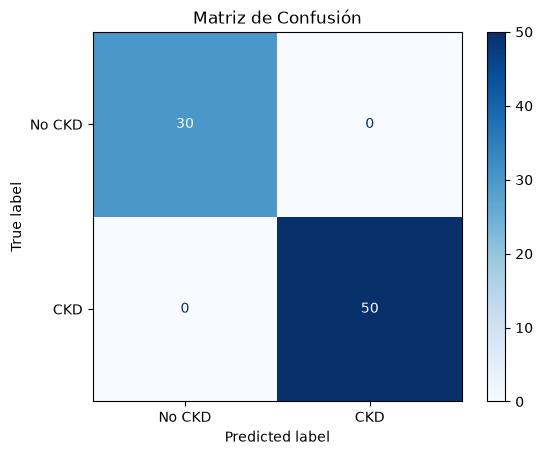

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No CKD', 'CKD'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.savefig('confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 Resultado y explicaciones con SHAP

In [21]:
explainer_shap = shap.TreeExplainer(rf)
shap_values_obj = explainer_shap(X_test_sc)

# para clasificacion binaria tomamos la clase CKD (indice 1)
shap_vals = shap_values_obj[:, :, 1].values
print(f"Shape SHAP values: {shap_vals.shape}")

Shape SHAP values: (80, 24)


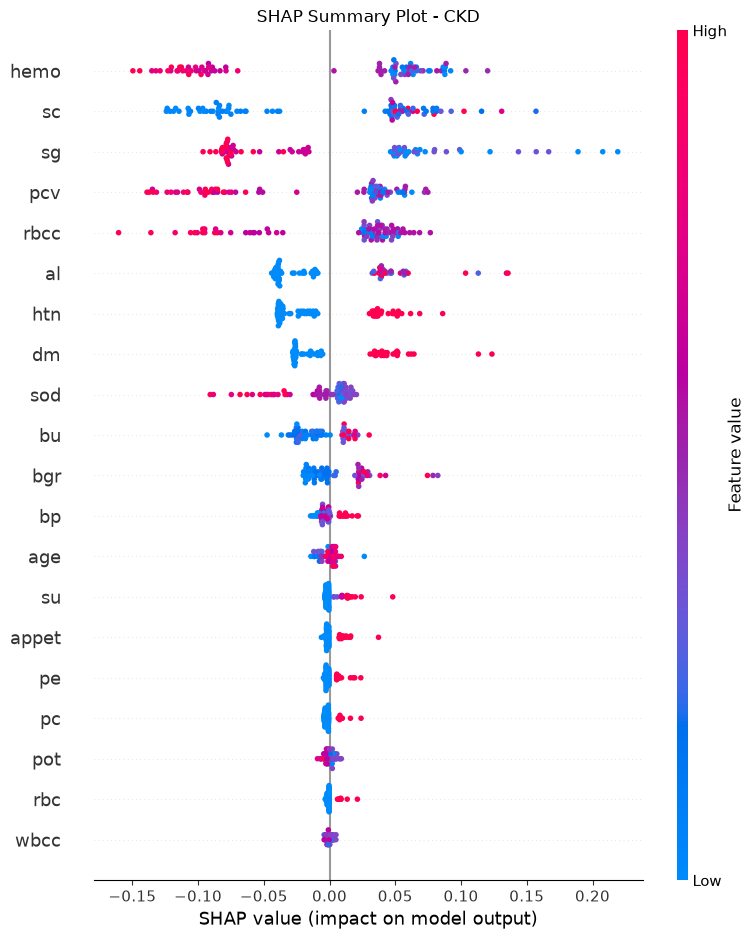

In [22]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test_sc, show=False)
plt.title('SHAP Summary Plot - CKD')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

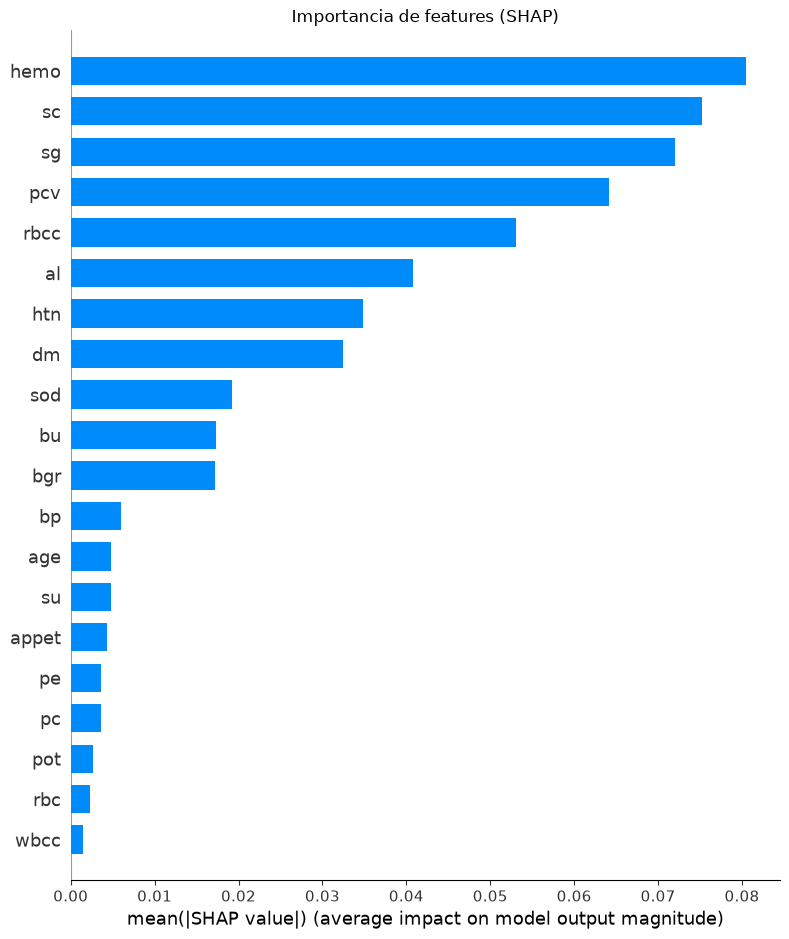

In [23]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test_sc, plot_type='bar', show=False)
plt.title('Importancia de features (SHAP)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Paciente idx=1 | Pred: CKD | Real: CKD


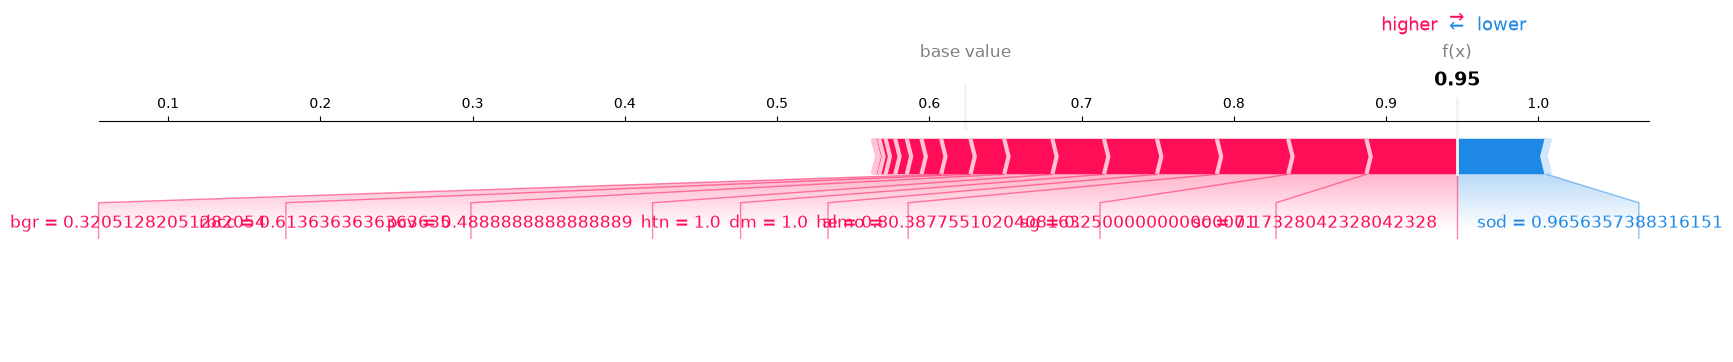

<Figure size 640x480 with 0 Axes>

In [24]:
# explicacion local: un paciente clasificado como CKD
idx_ckd = np.where(y_pred == 1)[0][0]
print(f"Paciente idx={idx_ckd} | Pred: CKD | Real: {'CKD' if y_test.iloc[idx_ckd] == 1 else 'No CKD'}")

shap.initjs()
shap.force_plot(
    explainer_shap.expected_value[1],
    shap_vals[idx_ckd],
    X_test_sc.iloc[idx_ckd],
    matplotlib=True
)
plt.savefig('shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

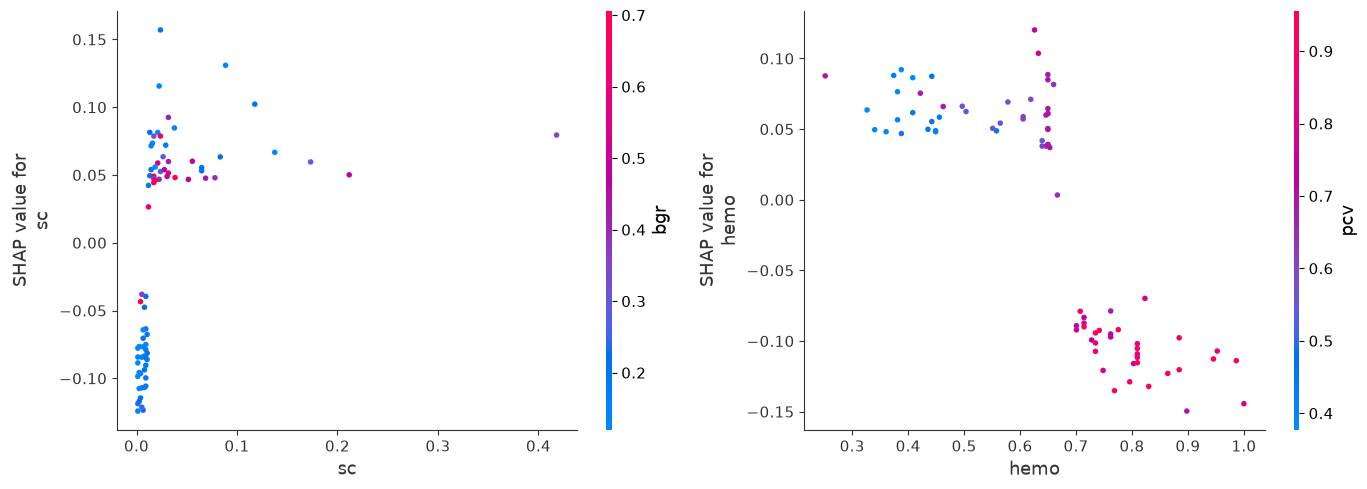

In [25]:
# dependence plot de las 2 features con mayor impacto
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top2_idx = np.argsort(mean_abs_shap)[-2:]
top2_features = X_test_sc.columns[top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(top2_features):
    plt.sca(axes[i])
    shap.dependence_plot(feat, shap_vals, X_test_sc, show=False, ax=axes[i])

plt.tight_layout()
plt.savefig('shap_dependencia.png', dpi=150, bbox_inches='tight')
plt.show()